# 07 - SHAP Interpretability

This notebook uses SHAP (SHapley Additive exPlanations) to explain what drives the flags produced by the two machine-learning detectors: the Isolation Forest (notebook 03) and the LSTM autoencoder (notebook 04). The goal is to explain, at the feature level, why these two detectors are so orthogonal to each other and to the ±3σ baseline, a question raised by the agreement analysis in notebook 05.

The Isolation Forest is explained with TreeExplainer, which computes exact SHAP values for tree-based models. The LSTM autoencoder has no exact SHAP method for sequence models, so it is explained with GradientExplainer, a gradient-based approximation applied to a sample of sequences.

**Outputs**
- `results/shap_summary_isoforest.png`, a SHAP summary plot showing which features drive the Isolation Forest's anomaly scores
- `data/shap_lstm_importance.csv`, mean absolute SHAP value per feature for the LSTM autoencoder

## 1. Refitting the Isolation Forest

SHAP needs direct access to the fitted model, so the Isolation Forest is refit here with the same parameters used in notebook 03. Since `random_state=42` is fixed, this reproduces the exact same model rather than a new one, so the SHAP explanations below apply to the actual detector used throughout the project.

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest

DATA_DIR = Path("../data")

# reload the feature matrix
features = pd.read_parquet(DATA_DIR / "features_clean.parquet")
feature_cols = ["ret_zscore", "vol_5", "vol_20", "vol_60", "vol_zscore"]
X = features[feature_cols].values

# refit the Isolation Forest (same params as detector 2 — reproducible via seed)
iso = IsolationForest(n_estimators=100, contamination=0.007, random_state=42, n_jobs=-1)
iso.fit(X)

print("Forest refitted. Features:", feature_cols)
print("SHAP version:", shap.__version__)

Forest refitted. Features: ['ret_zscore', 'vol_5', 'vol_20', 'vol_60', 'vol_zscore']
SHAP version: 0.52.0


## 2. Building the Explanation Sample

Run SHAP on all flagged days plus a random sample of 5,000 normal days, rather than the full 1.18 million-row dataset. This keeps the explanation focused on the days that matter (the flags) while still including enough normal days for the summary plot to show contrast between flagged and unflagged behavior.

In [2]:
# get the forest's flags so we can focus SHAP on flagged days
features = features.copy()
features["iso_anomaly"] = iso.predict(X) == -1

# build an explanation sample: all flagged days + a random sample of normal days
flagged_idx = np.where(features["iso_anomaly"].values)[0]
normal_idx  = np.where(~features["iso_anomaly"].values)[0]
np.random.seed(42)
normal_sample = np.random.choice(normal_idx, size=5000, replace=False)

explain_idx = np.concatenate([flagged_idx, normal_sample])
X_explain = X[explain_idx]
print("Explaining", len(X_explain), "rows (all flagged +5000 normal)")

# TreeExplainer — the fast, exact SHAP method for tree models
explainer = shap.TreeExplainer(iso)
shap_values = explainer.shap_values(X_explain)
print("SHAP values shape:", shap_values.shape)

Explaining 13290 rows (all flagged +5000 normal)
SHAP values shape: (13290, 5)


## 3. Visualizing Isolation Forest Feature Importance

<tmp>/ipykernel_21232/2933006007.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


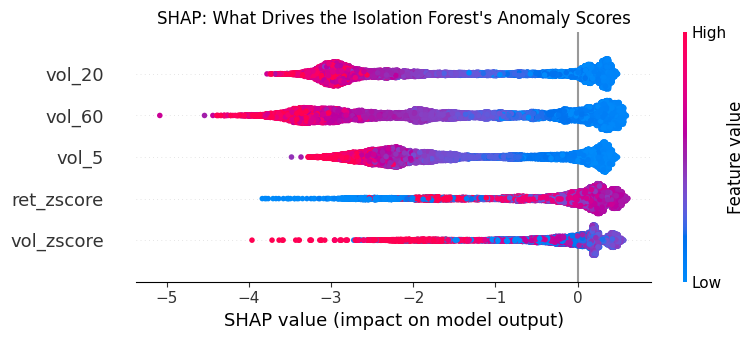

In [3]:
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_cols,
    show=False,
)
plt.title("SHAP: What Drives the Isolation Forest's Anomaly Scores")
plt.tight_layout()
plt.savefig("../results/shap_summary_isoforest.png", dpi=150, bbox_inches="tight")
plt.show()

### SHAP: Why the Isolation Forest Flags What It Flags

SHAP values quantify how much each feature contributes to the model's anomaly score for each stock-day. This plot ranks the five features by their overall influence, and each dot is one stock-day, colored by whether that feature's value was high (red) or low (blue).

The result is unambiguous. The three volatility features (vol_20, vol_60, vol_5) dominate, while return surprise (ret_zscore) and volume surprise (vol_zscore) contribute little. Reading the color, high volatility (red) produces large negative SHAP values, pushing days toward being flagged as anomalous, while return and volume surprise cluster near zero regardless of value.

Mechanically, the Isolation Forest is a volatility-state detector. This explains its behavior throughout the project: why it flagged the 2020 crash heavily (extreme volatility), why it barely overlaps the return-driven ±3σ baseline (a different feature entirely), and why its flags predict return continuation. The detectors disagree because they are driven by different features, and SHAP makes that concrete.

## 4. Reloading the LSTM Autoencoder

Rebuild the same architecture used in notebook 04 and load the trained (v2) weights, so SHAP explains the actual detector rather than a fresh, untrained model.

In [4]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# rebuild the architecture (must match training exactly)
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features=5, hidden_size=64, seq_len=30):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_size = hidden_size
        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, n_features)
    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        latent = hidden[-1].unsqueeze(1).repeat(1, self.seq_len, 1)
        decoded, _ = self.decoder(latent)
        return self.output_layer(decoded)

model = LSTMAutoencoder(hidden_size=64).to(device)
model.load_state_dict(torch.load(DATA_DIR / "lstm_autoencoder.pth"))
model.eval()
print("LSTM reloaded.")

LSTM reloaded.


In [5]:
import shap

# we'll rebuild the sequences (or reload if still in memory)
# SHAP needs a scalar output, so wrap: input sequence -> reconstruction error
def lstm_score(x_numpy):
    x = torch.tensor(x_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        recon = model(x)
        err = ((recon - x) ** 2).mean(dim=(1, 2))   # one error per sequence
    return err.cpu().numpy()

print("Scoring wrapper ready.")

Scoring wrapper ready.


SHAP explainers expect a function that maps inputs to a single scalar output, so the model above is wrapped to return reconstruction error per sequence rather than the full reconstructed sequence.

## 5. Rebuilding Sequences

Reconstruct the same 30-day sequences used to train and score the LSTM in notebook 04, since SHAP needs to run on that same input format.

In [6]:
def make_sequences(stock_features, window=30):
    sequences = []
    for i in range(len(stock_features) - window + 1):
        sequences.append(stock_features[i : i + window])
    return np.array(sequences)

all_sequences = []
sequence_index = []
for ticker in features.index.get_level_values("Ticker").unique():
    stock = features.xs(ticker, level="Ticker").sort_index()
    arr = stock[feature_cols].values
    if len(arr) < 30:
        continue
    seqs = make_sequences(arr, window=30)
    all_sequences.append(seqs)
    sequence_index.extend([(d, ticker) for d in stock.index[29:]])

X_seq = np.concatenate(all_sequences, axis=0)
print("Sequences rebuilt:", X_seq.shape)

Sequences rebuilt: (1169720, 30, 5)


## 6. Computing LSTM SHAP Values

GradientExplainer needs a small background set to estimate a baseline and a set of inputs to explain. Both are kept small (100 background sequences, 200 to explain) since gradient-based SHAP is far more expensive per sample than tree-based SHAP. This runs on CPU because PyTorch's cuDNN RNN backward pass does not support the double-backward operation the gradient explainer needs.

In [13]:
import shap
np.random.seed(42)

# --- move everything to CPU for SHAP (avoids the cuDNN RNN-backward restriction) ---
cpu = torch.device("cpu")

# rebuild the scored wrapper on CPU
class LSTMScoreWrapper(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        self.ae = autoencoder
    def forward(self, x):
        recon = self.ae(x)
        err = ((recon - x) ** 2).mean(dim=(1, 2))
        return err.unsqueeze(1)

model_cpu = LSTMAutoencoder(hidden_size=64).to(cpu)
model_cpu.load_state_dict(torch.load(DATA_DIR / "lstm_autoencoder.pth", map_location=cpu))
scored_model = LSTMScoreWrapper(model_cpu).to(cpu)
scored_model.train()   # training mode enables gradient machinery (does NOT retrain)

# small sampled sets, on CPU
bg_idx      = np.random.choice(len(X_seq), size=100, replace=False)
explain_idx = np.random.choice(len(X_seq), size=200, replace=False)
background = torch.tensor(X_seq[bg_idx], dtype=torch.float32)
to_explain = torch.tensor(X_seq[explain_idx], dtype=torch.float32)

explainer = shap.GradientExplainer(scored_model, background)
shap_values = explainer.shap_values(to_explain)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (200, 30, 5, 1)


## 7. Aggregating Feature Importance

Average the absolute SHAP values across all sequences and all 30 timesteps to get one importance score per feature, collapsing away both the sequence and the time dimension.

In [14]:
# shape: (200, 30, 5, 1) -> drop the trailing 1
sv = np.array(shap_values).squeeze(-1)   # now (200, 30, 5)

# mean absolute SHAP per feature: average across sequences AND timesteps
feature_importance = np.abs(sv).mean(axis=(0, 1))   # collapse dims 0 and 1 -> (5,)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": feature_importance,
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df.to_string(index=False))

   feature  mean_abs_shap
vol_zscore       0.001366
ret_zscore       0.000368
     vol_5       0.000028
    vol_20       0.000021
    vol_60       0.000012


### SHAP: What Drives the LSTM (and How It Differs from the Forest)

Using gradient-based SHAP on a sample of sequences, this estimates which features most influence the LSTM's reconstruction error. This is a coarser, exploratory attribution than the exact tree-SHAP used for the Isolation Forest, owing to the LSTM's sequential inputs.

The ranking is striking because it inverts the Isolation Forest. The LSTM is driven mainly by volume surprise (vol_zscore) and return surprise (ret_zscore), while the three volatility features, which dominated the Isolation Forest, contribute almost nothing. The two machine-learning detectors key on essentially opposite feature sets.

This explains the orthogonality found in notebook 05 from the inside. The detectors don't just behave differently, they are mechanically driven by different inputs. The Isolation Forest fires on volatility states, while the LSTM fires on sharp volume and return departures that break its learned temporal patterns. Different features lead to different flagged days, which lead to different subsequent returns. This interpretability layer confirms the three detectors are genuinely distinct instruments.

## 8. Saving LSTM Feature Importance

In [15]:
importance_df.to_csv(DATA_DIR / "shap_lstm_importance.csv", index=False)
print("Saved LSTM SHAP importance.")

Saved LSTM SHAP importance.
